# 05 Topics and Engagement

**What do people write about, and does language predict engagement?**

The two questions belong together because the second depends on the first.

If language predicts engagement, the obvious follow-up is which language. Topic modelling provides a way to identify the recurring themes and vocabulary associated with more and less engaged respondents.

The first part of this notebook therefore identifies the main topics in the comments. The second examines whether those topics, and the language used within them, are associated with engagement.

In [1]:
# ============================================================
# Imports
# ============================================================

import json
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. This run's outputs, and the outputs stored inside this")
    print("notebook's cells, contain real employee comments. Do not share the")
    print("executed copy.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

CIRCUMPLEX_FILE = WORK / f"{SOURCE}_circumplex.parquet"
OUTPUT = WORK / f"{SOURCE}_topics_engagement.parquet"

# ---- topics -----------------------------------------------------------------
CONFIG = DATA / "config"
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
OLLAMA = "http://127.0.0.1:11434"
LABEL_MODEL = "gemma2:9b"
RECOMPUTE = False
SEED = 42

# The configuration below is not chosen here. It is the result of the grid searches
# in private/04_topic_modeling_bertopic_high5.ipynb, carried over unchanged.
STOPWORDS_FILE = CONFIG / "german_stopwords_full.txt"   # the large list, 1,848 words
UMAP_NEIGHBOURS = 5        # winner of the UMAP search
UMAP_MIN_DIST = 0.0        # winner of the UMAP search
UMAP_COMPONENTS = 5
MIN_CLUSTER_SIZE = 5       # winner of the HDBSCAN search
NGRAM_RANGE = (1, 2)
MIN_DF = 2
N_TOPICS = 35              # reduce to this many after fitting

# Survey-tool artefacts. Left in, they form a topic of their own.
ARTEFACTS = r"#?ODTUTWASODSOTUT|#?ODTUTWASODTUT|\bcode\b"

# The fitted High5 model. Used ONLY when SOURCE == "real": it was trained on real
# comments, so the synthetic run must never touch it — that run always fits its own.
TOPIC_MODEL = DATA.parent / "models" / "bertopic_reduced_35"

BLUE, BLUE_SOFT, VIOLET, ORANGE = "#2a78d6", "#9ec5f4", "#4a3aa7", "#eb6834"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

data = pd.read_parquet(CIRCUMPLEX_FILE)
comments = data[data["has_comment"] == 1].copy()
print(f"{len(comments):,} comments")

2,500 comments


## Step 1 — Topics, fitted fresh

BERTopic embeds every comment, groups the embeddings, and identifies the characteristic words associated with each group.

**The model is fitted on the current corpus rather than loaded from a stored model.** A model trained on a different set of comments assigns new comments to previously learned topics. As the language of the corpus changes over time, more comments tend to fall into the outlier category because they no longer fit the existing topic structure.

In an earlier version of this project, a stored model classified 38% of the comments as outliers. Re-fitting the model on the current corpus avoids that problem and allows the topic structure to reflect the data being analysed.

The smallest admissible cluster is set to five comments — the value that came out of a search over HDBSCAN settings. It is a floor on what counts as a topic at all, not a share of the corpus, so the number of topics is free to grow with the dataset rather than being fixed in advance.

In [2]:
# ============================================================
# Fit BERTopic
# ============================================================

TOPIC_CACHE = WORK / f"{SOURCE}_topics.parquet"
KEYWORD_CACHE = WORK / f"{SOURCE}_topic_keywords.parquet"


def clean_for_topics(series):
    """Strip the survey-tool artefacts. Everything else is left untouched."""
    return (series.str.replace(ARTEFACTS, " ", regex=True, case=False)
            .str.replace(r"\s+", " ", regex=True).str.strip())


def build_model():
    """BERTopic exactly as private/04 left it — nothing tuned here."""
    from bertopic import BERTopic
    from bertopic.representation import KeyBERTInspired
    from bertopic.vectorizers import ClassTfidfTransformer
    from hdbscan import HDBSCAN
    from sentence_transformers import SentenceTransformer
    from sklearn.feature_extraction.text import CountVectorizer
    from umap import UMAP

    stopwords = [line.strip() for line
                 in STOPWORDS_FILE.read_text(encoding="utf-8", errors="replace").splitlines()
                 if line.strip() and not line.startswith(";")]
    print(f"  {len(stopwords):,} stopwords from {STOPWORDS_FILE.name}")

    return BERTopic(
        embedding_model=SentenceTransformer(EMBEDDING_MODEL),
        vectorizer_model=CountVectorizer(stop_words=stopwords,
                                         ngram_range=NGRAM_RANGE, min_df=MIN_DF),
        representation_model=KeyBERTInspired(),
        ctfidf_model=ClassTfidfTransformer(bm25_weighting=True),
        umap_model=UMAP(n_neighbors=UMAP_NEIGHBOURS, n_components=UMAP_COMPONENTS,
                        min_dist=UMAP_MIN_DIST, metric="cosine", random_state=SEED),
        hdbscan_model=HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, metric="euclidean",
                              cluster_selection_method="eom", prediction_data=True),
        language="multilingual",
        calculate_probabilities=False,      # only the assignment is needed
        verbose=False,
    )


if TOPIC_CACHE.exists() and not RECOMPUTE:
    topics = pd.read_parquet(TOPIC_CACHE)
    print(f"loaded {TOPIC_CACHE.name}")
else:
    import warnings as _warnings
    _warnings.filterwarnings("ignore")

    cleaned = clean_for_topics(comments["freitext_kommentar"])
    touched = int((cleaned != comments["freitext_kommentar"]).sum())
    print(f"artefacts removed from {touched:,} of {len(cleaned):,} comments")

    started = time.time()

    # --- real: reuse the fitted model, so the run reproduces the documented result
    if SOURCE == "real" and TOPIC_MODEL.exists():
        from bertopic import BERTopic

        print(f"loading {TOPIC_MODEL.name} and assigning "
              f"{len(cleaned):,} comments …", flush=True)
        model = BERTopic.load(str(TOPIC_MODEL))
        assigned, _ = model.transform(cleaned.tolist())

    # --- synthetic: always fits its own model and never sees the real one
    else:
        if SOURCE == "synthetic" and TOPIC_MODEL.exists():
            print("synthetic run: the High5 model is ignored on purpose, "
                  "this fit uses synthetic comments only")
        print(f"fitting on {len(cleaned):,} comments "
              f"(min_cluster_size={MIN_CLUSTER_SIZE}, seed={SEED}) …", flush=True)
        model = build_model()
        assigned, _ = model.fit_transform(cleaned.tolist())

        found = len({t for t in assigned if t != -1})
        if N_TOPICS and found > N_TOPICS:
            print(f"  {found} topics found, reducing to {N_TOPICS} …", flush=True)
            model.reduce_topics(cleaned.tolist(), nr_topics=N_TOPICS)
            assigned = model.topics_

    info = model.get_topic_info()
    keywords = {row["Topic"]: ", ".join(word for word, _ in model.get_topic(row["Topic"])[:10])
                for _, row in info.iterrows() if row["Topic"] != -1}
    topics = pd.DataFrame({"row": np.arange(len(comments)), "topic_id": assigned})
    topics.to_parquet(TOPIC_CACHE)
    pd.DataFrame([{"topic_id": t, "keywords": k} for t, k in keywords.items()]).to_parquet(
        KEYWORD_CACHE, index=False)
    print(f"done in {(time.time() - started) / 60:.1f} min")

comments["topic_id"] = topics["topic_id"].to_numpy()
keyword_table = pd.read_parquet(KEYWORD_CACHE)

outliers = (comments["topic_id"] == -1).sum()
print(f"{comments['topic_id'].nunique() - 1} topics plus an outlier group")
print(f"outliers: {outliers:,} comments ({outliers / len(comments):.0%})")


artefacts removed from 1 of 2,500 comments
synthetic run: the High5 model is ignored on purpose, this fit uses synthetic comments only
fitting on 2,500 comments (min_cluster_size=5, seed=42) …


  1,849 stopwords from german_stopwords_full.txt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  84 topics found, reducing to 35 …


done in 0.6 min
34 topics plus an outlier group
outliers: 329 comments (13%)


## Step 2 — Give the topics names

BERTopic describes a topic by its characteristic words. That is enough for analysis, but not for reporting, so the same local model that scored valence turns each keyword list into a short, human-readable label.

The labels are intended as summaries rather than definitive names. They help identify the main theme of a topic without replacing the underlying keywords.

Generating a label takes roughly two seconds per topic.

In [3]:
# ============================================================
# Topic Labels
# ============================================================

LABEL_PROMPT = (
    "Du bekommst die charakteristischen Begriffe eines Themas aus Freitext-"
    "kommentaren\neiner deutschen Mitarbeiterbefragung.\n\n"
    "Begriffe: {keywords}\n\n"
    "Gib eine kurze, sachliche Themenbezeichnung auf Deutsch, hoechstens vier "
    "Woerter.\nKeine Anfuehrungszeichen, keine Erklaerung, nur die Bezeichnung.\n\n"
    "Bezeichnung:"
)

LABEL_CACHE = WORK / f"{SOURCE}_topic_labels.parquet"

if LABEL_CACHE.exists() and not RECOMPUTE:
    labels = pd.read_parquet(LABEL_CACHE)
    print(f"loaded {LABEL_CACHE.name}")
else:
    def name_topic(keywords: str) -> str:
        try:
            response = requests.post(f"{OLLAMA}/api/chat", json={
                "model": LABEL_MODEL,
                "messages": [{"role": "user",
                              "content": LABEL_PROMPT.format(keywords=keywords)}],
                "stream": False, "keep_alive": "30m",
                "options": {"temperature": 0, "seed": 42, "num_predict": 20},
            }, timeout=120)
            response.raise_for_status()
            return response.json()["message"]["content"].strip().strip('"').split("\n")[0]
        except Exception:
            return ""

    print(f"naming {len(keyword_table)} topics …", flush=True)
    labels = keyword_table.copy()
    labels["topic_label"] = [name_topic(k) or f"Thema {t}"
                             for t, k in zip(labels["topic_id"], labels["keywords"])]
    labels.to_parquet(LABEL_CACHE, index=False)

lookup = dict(zip(labels["topic_id"], labels["topic_label"]))
lookup[-1] = "Ohne Thema"
comments["topic_label"] = comments["topic_id"].map(lookup)

sizes = comments["topic_label"].value_counts()
print(f"\n{'topic':38s} {'comments':>9s} {'share':>7s}")
for label, count in sizes.items():
    print(f"{str(label)[:38]:38s} {count:9,} {count / len(comments):6.0%}")

naming 34 topics …



topic                                   comments   share
Ohne Thema                                   329    13%
Informationsfluss im Unternehmen             212     8%
Strategiekommunikation                       207     8%
Arbeitsumfeld und Wohlbefinden               205     8%
Arbeitsbelastung                             196     8%
Flexible Arbeitszeit                         191     8%
Fehlerkultur im Unternehmen                  162     6%
Kommunikation Führungskräfte                 153     6%
Teamwork und Zusammenarbeit                  136     5%
Wertschätzung und Feedback                   100     4%
Ineffiziente Prozesse                         72     3%
Prozessoptimierung                            68     3%
Mitarbeiterentwicklung                        64     3%
Entscheidungswege und Verantwortung           64     3%
Weiterbildungswünsche                         54     2%
Weiterbildungsmöglichkeiten                   52     2%
Teamzusammenarbeit                            

### The same topics as a map

The table above says how large each topic is. It does not say which topics sit close to
one another, and that is often the more useful question: two themes that keep appearing
in the same words are two views of one problem rather than two problems.

Every comment is embedded into a 384-dimensional space by the same sentence model
BERTopic used, and those vectors are projected down to two dimensions for display. The
axes carry no units and are deliberately left unlabelled. **Only proximity means
anything**: points near each other were written in similar language.

The projection is computed once and cached, so this cell is fast on later runs. It does
not re-fit BERTopic — the topic assignments are the ones from Step 1.

loaded synthetic_topic_map.parquet


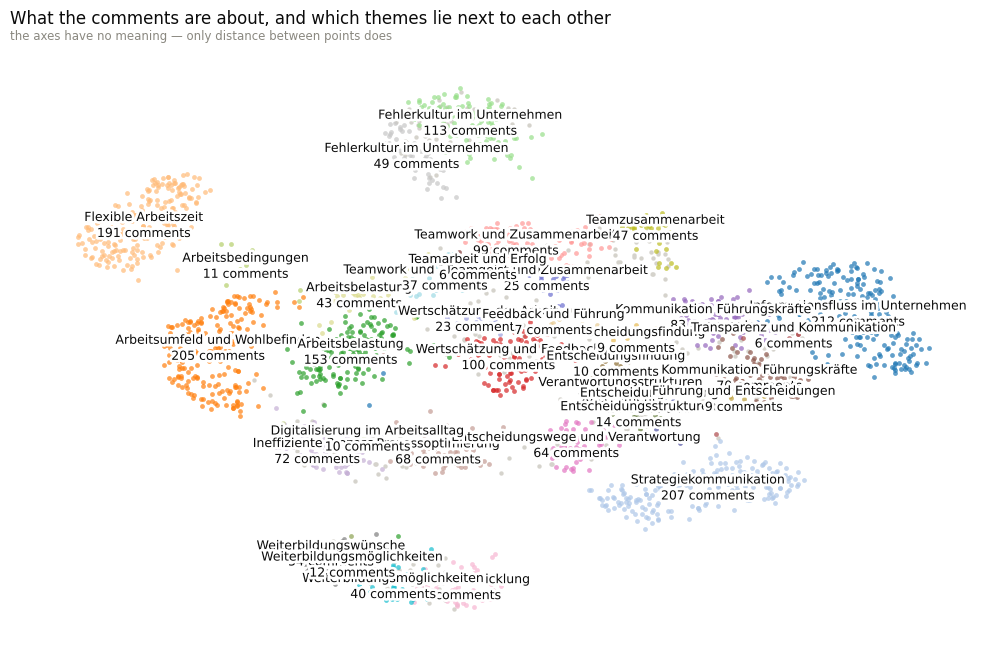

In [4]:
import matplotlib.patheffects as pe

# ============================================================
# The Topic Map
# ============================================================

MAP_CACHE = WORK / f"{SOURCE}_topic_map.parquet"

if MAP_CACHE.exists() and not RECOMPUTE:
    coordinates = pd.read_parquet(MAP_CACHE)
    print(f"loaded {MAP_CACHE.name}")
else:
    from sentence_transformers import SentenceTransformer
    from umap import UMAP

    print(f"embedding {len(comments):,} comments and projecting to 2-D …", flush=True)
    started = time.time()
    vectors = SentenceTransformer(EMBEDDING_MODEL).encode(
        comments["freitext_kommentar"].tolist(), show_progress_bar=False)
    # a projection for the eye, not for the model: cosine distance because that is what
    # the sentence embeddings are trained for, and a fixed seed so the picture is stable
    placed = UMAP(n_components=2, n_neighbors=60, min_dist=0.6,
                  metric="cosine", random_state=42).fit_transform(vectors)
    coordinates = pd.DataFrame(placed, columns=["x", "y"])
    coordinates.to_parquet(MAP_CACHE, index=False)
    print(f"done in {(time.time() - started) / 60:.1f} min")

chart = coordinates.copy()
chart["topic_id"] = comments["topic_id"].to_numpy()
chart["topic_label"] = comments["topic_label"].to_numpy()

named = [t for t in sorted(chart["topic_id"].unique()) if t != -1]
# tab20 alone runs out at 20 topics; the tuned model produces more, so three
# qualitative maps are chained to 60 distinct colours before any repeat.
wheel = (plt.colormaps["tab20"].colors + plt.colormaps["tab20b"].colors
         + plt.colormaps["tab20c"].colors)
palette = {t: wheel[i % len(wheel)] for i, t in enumerate(named)}

fig, ax = plt.subplots(figsize=(10.5, 7.2))
fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.04)

# the outlier group first and in grey, so it never covers a real topic
outlying = chart[chart["topic_id"] == -1]
ax.scatter(outlying["x"], outlying["y"], s=10, color="#d5d3cc", linewidths=0, zorder=1)

for topic_id in named:
    part = chart[chart["topic_id"] == topic_id]
    ax.scatter(part["x"], part["y"], s=12, color=palette[topic_id], alpha=0.7,
               linewidths=0, zorder=2)

# the median is the centre of mass a stray point cannot drag away
for topic_id in named:
    part = chart[chart["topic_id"] == topic_id]
    ax.annotate(
        f"{part['topic_label'].iloc[0]}\n{len(part)} comments",
        xy=(part["x"].median(), part["y"].median()),
        ha="center",
        va="center",
        fontsize=9,
        color=INK,
        linespacing=1.3,
        zorder=3,
        path_effects=[pe.withStroke(linewidth=4, foreground="white")],
    )

ax.margins(0.08)
ax.set_axis_off()
ax.set_title(
    "What the comments are about, and which themes lie next to each other",
    fontsize=12,
    loc="left",
    pad=16,
)
ax.text(0, 1.005, "the axes have no meaning — only distance between points does",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED, va="bottom")

plt.show()

## Step 3 — Does language predict engagement?

`engagement_score` is the mean of five closed survey items:

- Recognition
- Employer recommendation
- Joy at work
- Work-life balance
- Overload (reverse-coded)

The resulting score is not a standardised engagement scale. Instead, it serves as a compact indicator of overall employee experience by combining several outcomes that organisations typically care about.

Higher scores reflect employees who report more positive experiences across these dimensions, whereas lower scores reflect less positive experiences.

**The target comes from the survey, while the predictors come only from the comments.** Including the survey items themselves as model features would simply reconstruct the target from its own components and provide no insight into what can be learned from language.

The question is therefore not whether engagement can be measured directly from survey responses, but how much information different text representations contribute.

Three nested feature sets address that question. All models use the same algorithm and the same cross-validation folds. The only difference is the information provided to the model.

| Model | Features |
| :--- | :--- |
| baseline | none — predicts the mean |
| **1** | valence |
| **2** | valence + arousal + comment length |
| **3** | valence + arousal + comment length + TF-IDF |

The regularisation strength is selected separately within each training fold. This prevents information from the test data from influencing model selection and provides a more realistic estimate of predictive performance.

In [5]:
# ============================================================
# Three Nested Models
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

frame = comments[["valence", "arousal", "word_count", "freitext_kommentar",
                  "engagement_score", "bereich_ebene"]].dropna().copy()
frame["log_length"] = np.log1p(frame["word_count"])
frame = frame.rename(columns={"freitext_kommentar": "comment",
                              "engagement_score": "target"})

ALPHAS = np.logspace(-1, 4, 12)
FOLDS = KFold(n_splits=5, shuffle=True, random_state=42)
DENSE = ["valence", "arousal", "log_length"]
FEATURES = frame[["comment", "bereich_ebene"] + DENSE]


def evaluate(columns, with_text=False, with_area=False, estimator=None):
    steps = [("dense", StandardScaler(), columns)]
    if with_text:
        steps.append(("text", TfidfVectorizer(min_df=5, max_df=0.6, sublinear_tf=True),
                      "comment"))
    if with_area:
        steps.append(("area", OneHotEncoder(handle_unknown="ignore"), ["bereich_ebene"]))
    # explicitly against None: an unfitted RandomForest is falsy, because bool()
    # falls back to __len__ and that raises before it is trained
    model = estimator if estimator is not None else RidgeCV(alphas=ALPHAS)
    pipeline = Pipeline([("features", ColumnTransformer(steps)), ("model", model)])
    scores = cross_val_score(pipeline, FEATURES, frame["target"], cv=FOLDS, scoring="r2")
    return scores.mean(), scores.std()


results = pd.DataFrame([
    dict(zip(["model", "R2", "R2 sd"], ("baseline (mean)",)
             + evaluate(["valence"], estimator=DummyRegressor(strategy="mean")))),
    dict(zip(["model", "R2", "R2 sd"], ("1 · valence",) + evaluate(["valence"]))),
    dict(zip(["model", "R2", "R2 sd"], ("2 · + arousal, length",) + evaluate(DENSE))),
    dict(zip(["model", "R2", "R2 sd"], ("3 · + TF-IDF",)
             + evaluate(DENSE, with_text=True))),
    dict(zip(["model", "R2", "R2 sd"], ("2 · random forest",)
             + evaluate(DENSE, estimator=RandomForestRegressor(
                 n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)))),
])
print(results.round(4).to_string(index=False))

spread = float(results.loc[results["model"] == "1 · valence", "R2 sd"].iloc[0])
base = float(results.loc[results["model"] == "1 · valence", "R2"].iloc[0])
print(f"\nfold-to-fold spread of model 1: {spread:.3f} — the yardstick for calling a")
print("difference real\n")
for name in ["2 · + arousal, length", "3 · + TF-IDF", "2 · random forest"]:
    gain = float(results.loc[results["model"] == name, "R2"].iloc[0]) - base
    print(f"  {name:24s} {gain:+.4f}   "
          f"{'beyond the noise' if abs(gain) > spread else 'within the noise'}")

                model      R2  R2 sd
      baseline (mean) -0.0017 0.0015
          1 · valence  0.1858 0.0247
2 · + arousal, length  0.1851 0.0234
         3 · + TF-IDF  0.1844 0.0216
    2 · random forest  0.0989 0.0310

fold-to-fold spread of model 1: 0.025 — the yardstick for calling a
difference real

  2 · + arousal, length    -0.0007   within the noise
  3 · + TF-IDF             -0.0014   within the noise
  2 · random forest        -0.0869   beyond the noise


Valence alone explains a meaningful share of the variation in engagement (`R² = 0.186`). Neither arousal nor comment length improve the prediction, and adding thousands of TF-IDF features does not increase performance either.

The differences between models 1, 2, and 3 are smaller than the natural variation between cross-validation folds. In practical terms, the additional text features contribute no reliable signal beyond the valence measure already established in Notebook 02.

The random-forest model performs substantially worse, suggesting that the limitation is not the choice of algorithm. On this corpus, engagement appears to be related primarily to how positively or negatively people write, rather than to specific vocabulary patterns.

**This null result is a property of the synthetic corpus rather than a general finding.** On the real survey the same three models do separate, and TF-IDF adds measurably beyond valence. The comparison at the end of this notebook puts the two runs side by side and explains why the synthetic data cannot reproduce that effect.

For the remainder of this notebook, topics are therefore treated as descriptive rather than predictive. They help explain what employees talk about, but they do not add measurable predictive power beyond valence.

## Step 4 — The confound worth checking

If TF-IDF improves prediction, one interpretation is that vocabulary contains additional information about engagement.

Another possibility is that vocabulary reflects organisational structure rather than engagement itself. Different departments often use different terminology, and departments may also differ in their average engagement levels. In that case, the model could appear to learn engagement while actually learning departmental membership.

Organisation-specific terms make this difficult to assess by inspecting coefficients alone. The simplest test is therefore direct: replace the text features with department information and measure how much of the observed predictive performance can be reproduced.

In [6]:
# ============================================================
# Department or Language?
# ============================================================

text_only = float(results.loc[results["model"] == "3 · + TF-IDF", "R2"].iloc[0])
area_only, area_sd = evaluate(DENSE, with_area=True)
both, both_sd = evaluate(DENSE, with_text=True, with_area=True)

print(f"{'model':38s} {'R2':>8s}")
print(f"{'1 · valence':38s} {base:8.4f}")
print(f"{'3 · + TF-IDF':38s} {text_only:8.4f}")
print(f"{'2 · + department instead of text':38s} {area_only:8.4f}")
print(f"{'2 · + TF-IDF and department':38s} {both:8.4f}")

text_gain = text_only - base
area_gain = area_only - base
print(f"\ngain from text:       {text_gain:+.4f}")
print(f"gain from department: {area_gain:+.4f}")
if text_gain > 0:
    print(f"share of the text gain the department alone reproduces: "
          f"{max(0.0, area_gain) / text_gain:.0%}")
print("\nA large share means the text is identifying the department; a small one means")
print("the vocabulary carries something the department does not.")

model                                        R2
1 · valence                              0.1858
3 · + TF-IDF                             0.1844
2 · + department instead of text         0.1838
2 · + TF-IDF and department              0.1839

gain from text:       -0.0014
gain from department: -0.0020

A large share means the text is identifying the department; a small one means
the vocabulary carries something the department does not.


Six models, one picture. The shaded band is the fold-to-fold spread of model 1: a bar
that ends inside it recovers no more of the engagement score than valence alone does,
whatever its point estimate suggests.

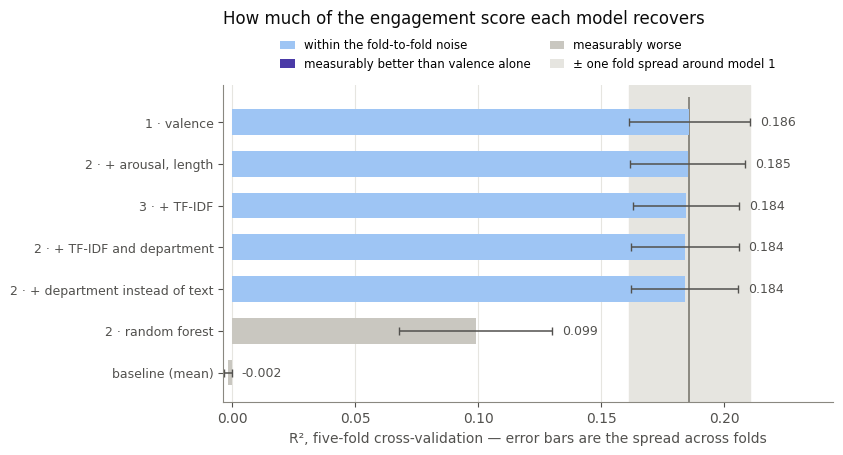

In [7]:
from matplotlib.patches import Patch

# ============================================================
# All Models, With Their Uncertainty
# ============================================================

GREY, BAND = "#c9c7c0", "#e6e5e0"

picture = pd.concat([
    results[["model", "R2", "R2 sd"]],
    pd.DataFrame([
        {"model": "2 · + department instead of text", "R2": area_only, "R2 sd": area_sd},
        {"model": "2 · + TF-IDF and department", "R2": both, "R2 sd": both_sd},
    ]),
], ignore_index=True).sort_values("R2", ascending=True).reset_index(drop=True)

# anything within one fold spread of model 1 is not distinguishable from it
lower, upper = base - spread, base + spread


def tone(value):
    if value > upper:
        return VIOLET
    if value < lower:
        return GREY
    return BLUE_SOFT


positions = np.arange(len(picture))
top = len(picture) - 1

fig, ax = plt.subplots(figsize=(10, 5.2))
fig.subplots_adjust(left=0.36, right=0.97, top=0.76, bottom=0.15)

# the band goes down first so the bars sit on top of it
ax.axvspan(lower, upper, color=BAND, zorder=0)
ax.vlines(base, -0.7, top + 0.6, color=INK_MUTED, lw=1.4, zorder=1)

ax.barh(
    positions,
    picture["R2"],
    xerr=picture["R2 sd"],
    color=[tone(value) for value in picture["R2"]],
    height=0.62,
    zorder=2,
    error_kw={"ecolor": INK_SOFT, "elinewidth": 1.1, "capsize": 3},
)

for y, (value, deviation) in enumerate(zip(picture["R2"], picture["R2 sd"])):
    ax.text(value + deviation + 0.004, y, f"{value:.3f}", va="center",
            color=INK_SOFT, fontsize=9)

ax.set_yticks(positions)
ax.set_yticklabels(picture["model"], fontsize=9)

ax.set_ylim(-0.7, top + 0.9)
ax.set_xlim(min(0.0, (picture["R2"] - picture["R2 sd"]).min() * 1.15),
            (picture["R2"] + picture["R2 sd"]).max() * 1.16)

ax.legend(
    handles=[
        Patch(facecolor=BLUE_SOFT, label="within the fold-to-fold noise"),
        Patch(facecolor=VIOLET, label="measurably better than valence alone"),
        Patch(facecolor=GREY, label="measurably worse"),
        Patch(facecolor=BAND, label="± one fold spread around model 1"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncols=2,
    frameon=False,
    fontsize=8.5,
    handlelength=1.2,
    columnspacing=1.6,
)

ax.grid(axis="y", visible=False)
ax.set_xlabel("R², five-fold cross-validation — error bars are the spread across folds")
ax.set_title(
    "How much of the engagement score each model recovers",
    fontsize=12,
    loc="left",
    pad=44,
)

plt.show()

On the synthetic data the test has nothing to separate. Neither text features nor department information improve on the valence-based model, replacing TF-IDF with department membership produces virtually the same result, and combining both adds no measurable predictive power. All differences are well within the variation observed across cross-validation folds.

That makes the outcome uninformative rather than reassuring: a test for a confound cannot report anything when neither of the two candidate sources carries signal in the first place.

**The same test on the real survey does separate, and it changes the interpretation.** There, department membership alone recovers roughly three quarters of what the vocabulary contributes, so the two overlap substantially. The comparison at the end of this notebook gives the figures.

### And do the topics themselves differ?

The models above ask whether *wording* predicts engagement. A blunter question is
whether the *topic* does: are the people who write about workload systematically less
engaged than the people who write about the office?

Each topic gets its mean engagement score and a 95% confidence interval. The interval
is what keeps this honest — a topic of 180 comments has a mean that wobbles, and
without the whiskers every ranking looks meaningful.

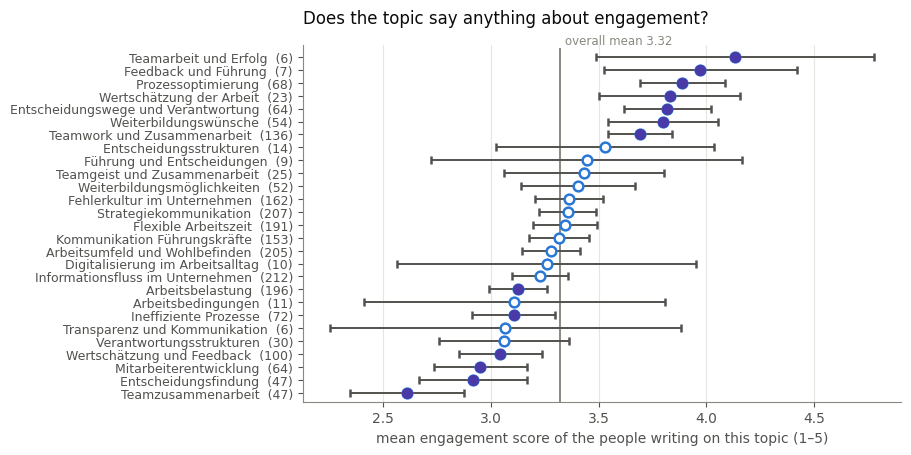

topics whose interval clears the overall mean: 13 of 27


In [8]:
# ============================================================
# Engagement per Topic
# ============================================================

per_topic = (comments[comments["topic_id"] != -1]
             .groupby("topic_label")["engagement_score"]
             .agg(["mean", "std", "size"]))
# 1.96 standard errors: the range the mean of this many comments would wander over
per_topic["margin"] = 1.96 * per_topic["std"] / np.sqrt(per_topic["size"])
per_topic = per_topic.sort_values("mean")

grand = comments["engagement_score"].mean()
# a topic stands out only if its whole interval lies to one side of the overall mean
apart = ((per_topic["mean"] - per_topic["margin"] > grand)
         | (per_topic["mean"] + per_topic["margin"] < grand))

positions = np.arange(len(per_topic))

fig, ax = plt.subplots(figsize=(9.5, 5.4))
fig.subplots_adjust(left=0.34, right=0.97, top=0.80, bottom=0.14)

ax.vlines(grand, -0.7, len(per_topic) - 0.3, color=INK_MUTED, lw=1.4, zorder=1)
ax.annotate(f"overall mean {grand:.2f}", xy=(grand, len(per_topic) - 0.25),
            xytext=(4, 0), textcoords="offset points", ha="left", va="bottom",
            color=INK_MUTED, fontsize=8.5)

ax.errorbar(
    per_topic["mean"], positions, xerr=per_topic["margin"],
    fmt="o", ms=7, capsize=3, lw=1.4, zorder=2,
    color=BLUE, ecolor=INK_SOFT, markerfacecolor="white", markeredgewidth=1.8,
)
# only the ones that clear the overall mean are filled in
standout = per_topic[apart]
ax.plot(standout["mean"], positions[apart.to_numpy()], "o", ms=7,
        color=VIOLET, zorder=3)

ax.set_yticks(positions)
ax.set_yticklabels([f"{label}  ({int(size)})"
                    for label, size in zip(per_topic.index, per_topic["size"])],
                   fontsize=9)
ax.set_ylim(-0.7, len(per_topic) - 0.1)

ax.grid(axis="y", visible=False)
ax.set_xlabel("mean engagement score of the people writing on this topic (1–5)")
ax.set_title("Does the topic say anything about engagement?", fontsize=12,
             loc="left", pad=16)

plt.show()

print(f"topics whose interval clears the overall mean: {int(apart.sum())} of {len(per_topic)}")

Of the 27 topics large enough to carry an interval, 13 clear the overall mean and 14 cross
it. So the topic is not uninformative — but for half the themes the interval is wide enough
to swallow the difference, and the ones that do separate are the clearly valenced themes.

That fits the model results rather than contradicting them. A comment about workload
reads more negatively than a comment about teamwork, so the topic shifts the valence
score, and engagement follows the valence. The path runs *through* valence rather than
around it. TF-IDF sees every word a topic label is built from, and it still adds nothing
once valence is in the model — which is what one would expect if there is no second
route.

## Step 5 — Hand over

In [9]:
# ============================================================
# Export
# ============================================================

for column in ["topic_id", "topic_label"]:
    data[column] = comments[column].reindex(data.index)

data.to_parquet(OUTPUT, index=False)
labels.to_csv(WORK / f"{SOURCE}_topic_labels.csv", index=False, sep=";",
              encoding="utf-8-sig")
results.to_csv(WORK / f"{SOURCE}_engagement_models.csv", index=False, sep=";",
               encoding="utf-8-sig", decimal=",")
print(f"written: {OUTPUT.name}, {SOURCE}_topic_labels.csv, "
      f"{SOURCE}_engagement_models.csv")

written: synthetic_topics_engagement.parquet, synthetic_topic_labels.csv, synthetic_engagement_models.csv


## Key Findings

**What people write about** is shown in the topic table above. These topics are specific to the corpus on which they were fitted and are not expected to transfer to other organisations. Re-fitting the model is part of the method rather than a limitation.

**Valence alone already answers the headline question.** A single sentiment measure explains a meaningful share of the variation in a five-item engagement score that it never saw during training. Text and questionnaire therefore capture overlapping aspects of the employee experience.

**Arousal adds no measurable predictive value.** Its contribution remains within the fold-to-fold variation of the cross-validation results. For this outcome, how positively or negatively people write matters more than how activated they appear.

**Vocabulary adds nothing beyond valence here, and neither does department membership.** Both stay within the fold-to-fold spread. On the synthetic corpus this is built in rather than discovered, for the reason given below.

**Free text complements rather than replaces surveys.** The target combines recognition, employer recommendation, joy at work, work-life balance, and overload. A short comment cannot fully represent all of these constructs, so a substantial share of the variance necessarily remains unexplained.

**All findings are conditional on writing a comment.** Only respondents who chose to provide free-text feedback are included in this analysis.

---

### Against the Real Data

| Metric | Synthetic | Real Survey |
|----------|----------:|----------:|
| R², valence alone | 0.186 | 0.147 |
| R², plus arousal and length | 0.185 | 0.150 |
| R², plus TF-IDF | 0.184 | 0.178 |
| R², plus department instead of text | 0.184 | 0.171 |
| R², plus TF-IDF and department | 0.184 | 0.190 |
| Random forest | 0.099 | worse than linear |
| Fold-to-fold spread of model 1 | 0.025 | 0.010 |

These are quality figures — how much of a scale a model recovers — so they can be
compared. What is not compared is the topic content: which themes an organisation's
comments fall into is a finding about that organisation.

**Models 1 and 2 agree; model 3 does not, and the difference is a property of the
generator.** The synthetic corpus was built to carry the length-to-engagement
relationship and the valence-to-criteria correlations, so the first two models are
partly calibrated rather than discovered. Nothing in the generation connected a
comment's theme to the survey answers, however. Themes were assigned independently of
the valence target, which leaves no path from wording to engagement other than through
valence — and the model already has valence. A TF-IDF model can only rediscover what it
was given, so the null result above is built in. **The relationship simply does not
exist in this dataset.** Synthetic comments also express themselves more plainly than
real ones, which tends to flatter every method that reads for meaning.

**On the real survey the relationship does exist, but the confound test reframes it.**
TF-IDF adds 0.031 beyond valence there, against a fold spread of 0.010, so the gain is
three times the noise. Department membership alone adds 0.024 — a little less than the
text, but on its own it already reproduces 76% of the text's gain. Taken together the two
add 0.043 rather than the 0.055 their separate gains would sum to, so they overlap: most
of what the vocabulary contributes is also available from knowing the department. What the
text adds on top of the department is 0.019, about twice the fold-to-fold spread.

The defensible reading is therefore not that words predict engagement on their own. It is
that **words largely identify the department, and departments differ in engagement.** A
small remainder survives the department, but at 0.019 it is close enough to the noise
floor that confirming it would need either a larger corpus or an analysis run within
departments rather than across them.